# Time Evolution of Quantum Spin Chains: Exact Diagonalisation and Qiskit Trotter Simulation

**Course:** PH10110 - Quantum Computing Group Project  
**Date:** March 2026  

---

## Abstract

We study the real-time dynamics of the one-dimensional anisotropic Heisenberg (XXZ) spin chain
by comparing three simulation strategies of increasing realism:
(i) exact sparse-matrix time evolution via the matrix exponential,
(ii) ideal first- and second-order Qiskit Trotter-Suzuki circuits simulated with `Statevector`, and
(iii) noisy Qiskit Trotter circuits simulated with `AerSimulator` in density-matrix mode using a
noise model derived from a real IBM QPU's calibration data via `NoiseModel.from_backend()`.
For an $L = 8$ site chain with open boundary conditions, we characterise
the space-time magnetisation dynamics and the two-dimensional Fourier spectrum of the
$\langle Z_i(t)\rangle$ observable. We quantify the Trotter approximation error as a function
of the number of time steps, confirming the expected $\mathcal{O}(\Delta t^p)$ convergence
for $p$-th order product formulas. The noisy Aer simulations, based on the calibration data of
`ibm_fez`, demonstrate that realistic device noise significantly degrades the long-time fidelity
of the evolution, illustrating both the utility of quantum-circuit simulation and the current
sensitivity of many-body dynamics to hardware imperfections.

## Table of Contents

1. [Introduction](#1-introduction)
2. [Problem Formulation and Theoretical Background](#2-problem-formulation-and-theoretical-background)
3. [Methods](#3-methods)
4. [Implementation Details](#4-implementation-details)
5. [Classical Benchmarks: Exact Time Evolution](#5-classical-benchmarks-exact-time-evolution)
6. [Quantum Simulation Results: Trotter Decomposition](#6-quantum-simulation-results-trotter-decomposition)
7. [Noisy Simulation Results](#7-noisy-simulation-results)
8. [Error Scaling Analysis](#8-error-scaling-analysis)
9. [Spectral Analysis](#9-spectral-analysis)
10. [Discussion](#10-discussion)
11. [Conclusion](#11-conclusion)
12. [Contribution Statement](#12-contribution-statement)
13. [References](#13-references)

## 1. Introduction

<a id="1-introduction"></a>


The real time evolution of interacting quantum many-body systems is one of the most important proposed applications of quantum computing. The central challenge in such systems is that the Hilbert-space dimension grows exponentially with system size. A chain of $L$ spin-$\tfrac12$ particles is described by a state in a $2^L$-dimensional complex vector space. As a result, exact classical simulation becomes increasingly expensive as $L$ increases, even for relatively simple lattice Hamiltonians. For this reason, quantum simulation has long been regarded as a natural setting in which quantum computers may eventually outperform classical methods [1-3]. In this project, the task is to study time evolution in a one-dimensional XXZ spin chain, measure $\langle X_i(t)\rangle$, $\langle Y_i(t)\rangle$, and $\langle Z_i(t)\rangle$ on every site, and compare quantum-circuit methods against classical benchmarks. 

In this study, an $L = 8$ spin chain with open boundary conditions is considered. The dynamics are generated by the XXZ Hamiltonian, which contains nearest neighbour $XX$, $YY$, and anisotropic $ZZ$ coupling terms. This model is a standard testbed for quantum simulation because it is simple enough to analyse at small size, but still rich enough to exhibit nontrivial many-body dynamics. Three representative cases are investigated: Two ferromagnetic cases with $J_z = 1.5$, starting from the fully polarised $|00\ldots0\rangle$ and $|11\ldots1\rangle$ states, and one antiferromagnetic case with $J_z = -1.5$, starting from the N\'eel-like state $|1010\ldots\rangle$. In each case, a spin near the middle of the chain is rotated into the equatorial plane of the Bloch sphere in order to create a local perturbation whose subsequent propagation can be tracked in time.

The aim of the project is not only to observe the resulting spin dynamics, but also to compare three different levels of simulation. First, exact classical time evolution is used as a benchmark reference. For $L = 8$, this is straightforward because the Hilbert-space dimension is only $2^8 = 256$, so the full state can still be evolved exactly using matrix-based methods. Second, the same dynamics are simulated using ideal Qiskit circuits based on Suzuki-Trotter decomposition [4], which approximates the full time-evolution operator by a sequence of local gates that can be implemented on a gate-based quantum computer. Third, noisy Qiskit simulations are performed in order to examine how realistic hardware noise affects the evolution. This structure follows the project brief closely, which explicitly calls for classical benchmarks, Trotter evolution, and an investigation of noise and errors. 

The main observables studied are the site-resolved expectation values $\langle X_i(t)\rangle$, $\langle Y_i(t)\rangle$, and $\langle Z_i(t)\rangle$, which are plotted as functions of both lattice site and time. These quantities show how the initial local disturbance spreads through the chain and how the behaviour depends on the interaction regime. Because the system size is small enough for exact classical benchmarking, this project does not aim to demonstrate a practical quantum advantage. Instead, its value is methodological. It provides a controlled setting in which the accuracy of Trotterised quantum circuits can be tested directly, the effect of finite Trotter step size can be assessed, and the impact of realistic noise can be measured before considering larger systems where exact classical simulation is no longer feasible.

Overall, the XXZ spin chain provides a clear and physically meaningful model in which to study both many-body quantum dynamics and the capabilities of current quantum simulation methods. By comparing exact classical evolution, ideal circuit simulation, and noisy circuit simulation within the same $L = 8$ framework, this report aims to determine how well quantum-circuit approaches reproduce the true dynamics and where their main limitations arise.

## 2. Problem Formulation and Theoretical Background

<a id="2-problem-formulation-and-theoretical-background"></a>

### 2.1 The XXZ Heisenberg Hamiltonian

The one-dimensional XXZ model on $L$ sites with open boundary conditions reads

$$
H = -\sum_{\langle i,j \rangle}
    \bigl(\sigma_i^x \sigma_j^x + \sigma_i^y \sigma_j^y + J_z\,\sigma_i^z \sigma_j^z\bigr),
\tag{1}
$$

where $\sigma_i^\alpha$ ($\alpha \in \{x,y,z\}$) are the Pauli matrices acting on site $i$,
and the sum runs over nearest-neighbour pairs $\langle i,j \rangle$.  The dimensionless
coupling $J_z$ controls the Ising anisotropy:

<div style="display: flex; justify-content: center;">
<table style="width: 85%; border-collapse: collapse; font-size: 0.95em;">
  <thead>
    <tr>
      <th style="padding: 6px; text-align: left;">Regime</th>
      <th style="padding: 6px; text-align: center;">J_z range</th>
      <th style="padding: 6px; text-align: left;">Physical character</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 6px;">Ferromagnetic</td>
      <td style="padding: 6px; text-align: center;">J_z > 1</td>
      <td style="padding: 6px;">Ising-like, spins prefer alignment</td>
    </tr>
    <tr>
      <td style="padding: 6px;">Isotropic (XXX)</td>
      <td style="padding: 6px; text-align: center;">J_z = 1</td>
      <td style="padding: 6px;">Full SU(2) symmetry</td>
    </tr>
    <tr>
      <td style="padding: 6px;">Critical (XY-like)</td>
      <td style="padding: 6px; text-align: center;"> -1 < J_z < 1 </td>
      <td style="padding: 6px;">Gapless Luttinger liquid</td>
    </tr>
    <tr>
      <td style="padding: 6px;">Antiferromagnetic Néel</td>
      <td style="padding: 6px; text-align: center;">J_z < -1</td>
      <td style="padding: 6px;">Alternating spin order</td>
    </tr>
  </tbody>
</table>
</div>

In this project three representative cases are studied:

- **Case A:** $J_z = 1.5$ (ferromagnetic), initial state all spins down ($|00\ldots 0\rangle$) with one spin rotated to the equator.
- **Case B:** $J_z = 1.5$ (ferromagnetic), initial state all spins up ($|11\ldots 1\rangle$) with one spin rotated.
- **Case C:** $J_z = -1.5$ (antiferromagnetic Néel), alternating initial state ($|1010\ldots\rangle$) with one spin rotated.

### 2.2 Time Evolution

The state of the system at time $t$ is given by the Schrödinger picture time evolution

$$
|\psi(t)\rangle = e^{-iHt}\,|\psi(0)\rangle,
\tag{2}
$$

where we set $\hbar = 1$.  Computing $e^{-iHt}$ exactly requires diagonalising the $2^L \times 2^L$
Hamiltonian matrix, which costs $\mathcal{O}(2^{3L})$ in general.  For our system size $L = 8$
($\mathrm{dim} = 256$), the matrix exponential `scipy.linalg.expm` is efficient enough
to serve as an exact benchmark.

### 2.3 Initial State Preparation

Each simulation case starts from a product state (a computational basis state) with a
single-site rotation that creates a local superposition.  For a site initially in $|0\rangle$,
we apply

$$
|\psi_{\mathrm{site}}\rangle = R_z(\phi)\,H\,|0\rangle
    = R_z(\phi)\,|+\rangle
    = \frac{1}{\sqrt{2}}\bigl(e^{-i\phi/2}|0\rangle + e^{+i\phi/2}|1\rangle\bigr),
\tag{3}
$$

with $\phi = \pi/3$.  This places the spin on the Bloch-sphere equator, breaking the $Z$
symmetry and generating non-trivial dynamics under $H$.

### 2.4 Observables

We track the local expectation values $\langle\sigma_i^\alpha(t)\rangle$ for
$\alpha \in \{X, Y, Z\}$ and all sites $i \in \{0, \ldots, L-1\}$.  These define a
space–time observable map of dimension $(n_t \times L \times 3)$.

The two-dimensional discrete Fourier transform of $\langle Z_i(t)\rangle$ yields the
momentum–frequency spectrum, allowing identification of the dispersion relation and
collective excitations of the spin chain.

## 3. Methods

<a id="3-methods"></a>

### 3.1 Exact Diagonalisation (Classical Benchmark)

For any integer number of qubits $L$, the Hamiltonian is represented as a $2^L \times 2^L$ matrix. In theory, one could diagonalise the 
initial Hamiltonian using standard eigenvalue/eigenvector decomposition and use the Maclaurin expansion of the
exponential of the matrix to evaluate the unitary operator's matrix. The issue with this is that it becomes highly impractical incredibly fast, 
thus it is more practical to implement the circuit computationally in almost all cases. The Hamiltonian is constructed by summing 
two-site Kronecker-product terms (Eq. 1) using SciPy sparse matrices. Then the time-evolved states' exponential
representation $U(\Delta t) = e^{-iH\Delta t}$ are computed using `scipy.linalg.expm`. Assuming the simplest
model of complexity where we require just $2^{2L}$ classical bits for each equivalent $L$-qubit Hamiltonian, 
this quickly scales: at $L=4$, the Hamiltonian is on the order of Bytes; at $L=8$, this increases to 
KBs, and by a simple case of $L=24$, the memory required is on the order of TBs. Thus this method is only suitable 
for small qubit systems.

### 3.2 Trotter-Suzuki Decomposition in Qiskit

The product-formula approach approximates the global evolution operator by splitting it into a sequence of 
local two-site unitaries. Writing $H = \sum_b H_b$ where $b$ labels nearest-neighbour bonds, we have:

**First-order Trotter:**
$$
e^{-iH\Delta t} \approx \prod_{b} e^{-iH_b\Delta t} + \mathcal{O}(\Delta t^2).
\tag{4}
$$
For improved accuracy, we use the symmetric second-order Suzuki--Trotter formula in the actual Qiskit implementation:
$$
U_2(\Delta t)
=
\prod_b e^{-iH_b\Delta t/2}
\prod_b^{\mathrm{reverse}} e^{-iH_b\Delta t/2}.
$$
Its symmetric structure cancels the leading lower-order commutator error present in the first-order formula, so the dominant local error is pushed to higher order in $\Delta t$.

In the Qiskit implementation, each two-site XXZ bond unitary is represented using the parametrized two-qubit gates `rxx`, `ryy`, and `rzz` [12]. For a single nearest-neighbour bond \(\langle i,j\rangle\), define
$$
h_{ij}= -\left(X_i\otimes X_j + Y_i\otimes Y_j + J_Z Z_i\otimes Z_j\right).
$$
Then the corresponding short-time evolution operator is
$$
e^{-ih_{ij}\Delta t}.
$$
Since \(X_i\otimes X_j\), \(Y_i\otimes Y_j\), and \(Z_i\otimes Z_j\) commute on the same bond, this factor can be written exactly as
$$
e^{-ih_{ij}\Delta t}
=
e^{i X_i\otimes X_j \Delta t}
e^{i Y_i\otimes Y_j \Delta t}
e^{i J_Z Z_i\otimes Z_j \Delta t}.
$$
Using the Qiskit gate definitions
$$
R_{XX}(\theta)=\exp\left(-i\frac{\theta}{2}X\otimes X\right),
$$
and similarly for \(R_{YY}\) and \(R_{ZZ}\), we obtain
$$
e^{-ih_{ij}\Delta t}
=
R_{XX}(-2\Delta t)\,
R_{YY}(-2\Delta t)\,
R_{ZZ}(-2J_Z\Delta t).
$$
Thus, the Trotter approximation enters in the ordering of different bond unitaries across the chain, while the decomposition of each individual two-site bond unitary into `rxx`, `ryy`, and `rzz` gates is exact.

This is easily implemented as a unitary operator in the circuit as can be seen in this circuit diagram for $L=4, \Delta t = 0.2, J_Z=-1.5$.
<p align="center">
    <img title="Unitary Operator with Paired Rotation Gates" alt="A quantum circuit diagram representing the unitary operator derived above with RXX, RYY, and RZZ gates" src="unitary.jpeg" height=250>
</p>

These two-qubit gates are entangling gates. Although the target two-site unitary remains the same, its explicit circuit decomposition depends on the universal gate set or hardware basis used during transpilation.  Below is the same unitary operator $U_{\Delta t}$ utilising the universal set for the IBM hardware ($CNOT, H, Rz, X \text{ and } \sqrt{X}$):

<p align="center">
    <img title="Decomposed Unitary Operator" alt="A quantum circuit diagram representing the unitary operator derived above with the IBM universal quantum gates set" src="unitary_decomposed.jpeg" height=450>
</p>

**Why Trotter decomposition is appropriate:** it is the simplest product-formula method,
well-understood theoretically, and directly expressible as a quantum circuit. Its error is
controllable: by increasing the number of Trotter steps $n$ (decreasing $\Delta t = T/n$),
the approximation converges to the exact evolution.

The Trotter decomposition simulation is incredibly simple. It follows the algorithm [10]:
$$
\begin{alignat*}{2}
&1. |\tilde{\psi}_0 \rangle \gets |\psi_0 \rangle; j=0 &\text{ initialise state}\\
&2. \to |\tilde{\psi}_{j+1}\rangle = U_{\Delta t} |\tilde{\psi}_{j}\rangle &\text{ iterative update} \\
&3. \to j=j+1; \text{ go to 2. until }  j\Delta t \geq t_f &\text{ loop} \\
&4. \to |\tilde{\psi}(t_f) \rangle = |\tilde{\psi}_j\rangle
\end{alignat*}
$$

This algorithm is also simple to implement as can be seen in this circuit for alternating initial states, and 5 timesteps.

<p align="center">
    <img title="Full Time Evolution Circuit" alt="A quantum circuit diagram representing the eime evolution circuit" src="quantum_simulation_circuit.jpeg" height=250>
</p>

### 3.3 Noisy Qiskit Aer Simulation

To model the effect of noise (e.g. decoherence from environmental coupling and control/calibration errors in gate implementations) on real hardware, the same Trotter 
circuits are simulated with `AerSimulator(method="density_matrix")` using a noise model derived
from the calibration data of a real IBM QPU. The `QiskitRuntimeService` class is used to
connect to the IBM Quantum Platform, retrieve the backend properties of `ibm_fez`, and 
construct the noise model via `NoiseModel.from_backend()`.

Each Trotter step is transpiled to the backend's native gate set using
`generate_preset_pass_manager(target=aer_sim.target)`, so the calibration-based noise
channels — including gate errors, thermal relaxation ($T_1$, $T_2$), and readout errors —
are applied to the correct operations. The initial many-body state is injected exactly
via `set_statevector`, so the comparison isolates the effect of dynamical gate noise
rather than state-preparation error.

The noisy simulation is performed deterministically in density-matrix form rather than by Monte
Carlo trajectory averaging, so the output directly gives the noisy expectation values
$\langle X_i(t)\rangle$, $\langle Y_i(t)\rangle$, and $\langle Z_i(t)\rangle$. This is useful
as it creates consistent noise that better matches the real expectation values but is less random,
meaning the simulation loses out on the real world Poisson-distributed random noise equivalence.

## 4. Implementation Details

<a id="4-implementation-details"></a>

This notebook is **self-contained**: all the code needed to reproduce every figure and table
is defined in the helper-function cell below. The main building blocks are:

- **Hamiltonian construction** using Kronecker products of Pauli matrices (extending the
  Workshop 3 approach from 2 sites to $L = 8$ sites, with `scipy.sparse` for efficiency);
- **Exact time evolution** via `scipy.linalg.expm`, the same matrix-exponential method
  used in Workshop 3;
- **Qiskit Trotter circuits** built from `rxx`, `ryy`, `rzz` gates, simulated with
  `Statevector` (ideal) and `AerSimulator` (noisy), extending the Trotter exercise
  from Workshop 3 and the noise modelling from Workshop 4;
- **Observable extraction** using `SparsePauliOp` expectation values, as demonstrated
  in the workshops.

Certain choices have been made to increase efficiency but are not the simplest methods
possible for the implementation. These are:
- **Sparse matrices** (SciPy CSR format) for the Hamiltonian, since for $L = 8$ the
  $256 \times 256$ matrix is mostly zeros.
- **A shared initial-state definition** used by the exact, ideal-Qiskit, and noisy-Qiskit
  pipelines so they all start from the same state.
- **Aer density-matrix simulation** for the noisy results, avoiding shot noise and giving
  direct access to expectation values.

In [1]:
# IBM Quantum API Setup.  Place downloaded API key JSON file in the same folder
import json
from qiskit_ibm_runtime import QiskitRuntimeService

try:
    with open("apikey.json") as f:
        api_key = json.load(f)
    token = api_key.get("apikey") or api_key.get("token") or api_key.get("api_key")
except FileNotFoundError:
    token = "PASTE_TOKEN_HERE"

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    instance="open-instance",
    token=token,
    overwrite=True,
    set_as_default=True,
)
print("API credentials saved successfully")

API credentials saved successfully


#### Method Definitions

This section defines all of the methods required to perform the simulations in later sections.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from scipy.linalg import expm

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

import qiskit
import qiskit_aer

from spin_chain_utils import (
    compute_all_observables,
    compute_energy_dm,
    compute_energy_pure,
    compute_fft2_magnitude,
    evolve_exact,
    get_initial_statevector,
    observable_rmse,
    plot_conserved_quantities,
    plot_figure1_exact_spacetime,
    plot_figure2_ideal_trotter_spacetime,
    plot_figure3_trotter_error,
    plot_figure4_exact_vs_noisy,
    plot_figure5_error_convergence,
    plot_figure6_fft_spectra,
    plot_lightcone_velocity,
    plot_reflection_time,
    run_ideal_trotter,
    run_noisy_trotter,
    state_infidelity,
    state_infidelity_dm,
    xxz_hamiltonian,
)

In [3]:
print(f"qiskit version: {qiskit.__version__}")
print(f"qiskit-aer version: {qiskit_aer.__version__}")



# Simulation parameters
L = 8
t_max = 6.0
n_times = 121
trotter_order = 2
error_steps = [20, 40, 80, 160]

times = np.linspace(0.0, t_max, n_times)
dt = times[1] - times[0]

print(f"System size: L = {L}  (Hilbert space dim = {2**L})")
print(f"Time grid: t in [0, {t_max}], {n_times} points, dt = {dt:.4f}")
print(f"Trotter order: {trotter_order}")

qiskit version: 2.3.0
qiskit-aer version: 0.17.2
System size: L = 8  (Hilbert space dim = 256)
Time grid: t in [0, 6.0], 121 points, dt = 0.0500
Trotter order: 2


### 4.1 Simulation Cases

Three physically distinct cases are implemented that probe different regimes of the XXZ model.
In each case a single spin is rotated from the background state to the Bloch-sphere equator
at site $i = L/2 = 4$ with azimuthal angle $\phi = \pi/3$, creating a localised excitation
whose subsequent spreading reveals the dynamics of the chain.

In [4]:
# Define three physically distinct cases as simple dictionaries
cases = [
    {
        'name': 'case_A_Jz_gt_1_all_down',
        'L': L,
        'Jz': 1.5,
        'boundary': 'open',
        'init_pattern': 'all0',
        'phi': float(np.pi / 3.0),
    },
    {
        'name': 'case_B_Jz_gt_1_all_up',
        'L': L,
        'Jz': 1.5,
        'boundary': 'open',
        'init_pattern': 'all1',
        'phi': float(np.pi / 3.0),
    },
    {
        'name': 'case_C_Jz_lt_minus1_alternating',
        'L': L,
        'Jz': -1.5,
        'boundary': 'open',
        'init_pattern': 'alternating10',
        'phi': float(np.pi / 3.0),
    },
]

for case in cases:
    state0, bitstring, rotate_site = get_initial_statevector(
        L=case['L'],
        init_pattern=case['init_pattern'],
        phi=case['phi'],
        rotate_site=case.get('rotate_site'),
    )
    print(f"  {case['name']}:")
    print(f"    Jz = {case['Jz']}, boundary = {case['boundary']}")
    print(f"    Initial bitstring = |{bitstring}>, rotated site = {rotate_site}")
    print(f"    ||psi0|| = {np.linalg.norm(state0):.6f}")

  case_A_Jz_gt_1_all_down:
    Jz = 1.5, boundary = open
    Initial bitstring = |00000000>, rotated site = 4
    ||psi0|| = 1.000000
  case_B_Jz_gt_1_all_up:
    Jz = 1.5, boundary = open
    Initial bitstring = |11111111>, rotated site = 4
    ||psi0|| = 1.000000
  case_C_Jz_lt_minus1_alternating:
    Jz = -1.5, boundary = open
    Initial bitstring = |10101010>, rotated site = 4
    ||psi0|| = 1.000000


## 5. Classical Benchmarks: Exact Time Evolution

<a id="5-classical-benchmarks-exact-diagonalisation"></a>

We first compute the exact dynamics using the sparse matrix exponential.  This serves as
the ground-truth reference for all subsequent comparisons.  For each case, we construct the
XXZ Hamiltonian (Eq. 1), prepare the initial state, and evaluate
$|\psi(t)\rangle = e^{-iHt}|\psi_0\rangle$ at 121 uniformly spaced time points in $t \in [0, 6]$.

The resulting local expectations $\langle\sigma_i^\alpha(t)\rangle$ are displayed as
space–time heatmaps (Figure 1), with the colour scale ranging from $-1$ (blue) to $+1$
(red).  These plots reveal how the initial local excitation propagates through the chain,
with the speed and pattern determined by the exchange coupling and anisotropy $J_z$.

In [5]:
exact_results = {}

for case in cases:
    state0, bitstring, rotate_site = get_initial_statevector(
        L=case['L'],
        init_pattern=case['init_pattern'],
        phi=case['phi'],
        rotate_site=case.get('rotate_site'),
    )
    H = xxz_hamiltonian(L=case['L'], Jz=case['Jz'], boundary=case['boundary'])

    states_exact = evolve_exact(H, state0, times)
    obs_exact = compute_all_observables(states_exact, case['L'])

    exact_results[case['name']] = {
        'states': states_exact,
        'obs': obs_exact,
        'state0': state0,
        'H': H,
        'bitstring': bitstring,
        'rotate_site': rotate_site,
        'case': case,
    }
    print(f"  {case['name']}: exact evolution computed ({states_exact.shape[0]} time steps)")

  case_A_Jz_gt_1_all_down: exact evolution computed (121 time steps)
  case_B_Jz_gt_1_all_up: exact evolution computed (121 time steps)
  case_C_Jz_lt_minus1_alternating: exact evolution computed (121 time steps)


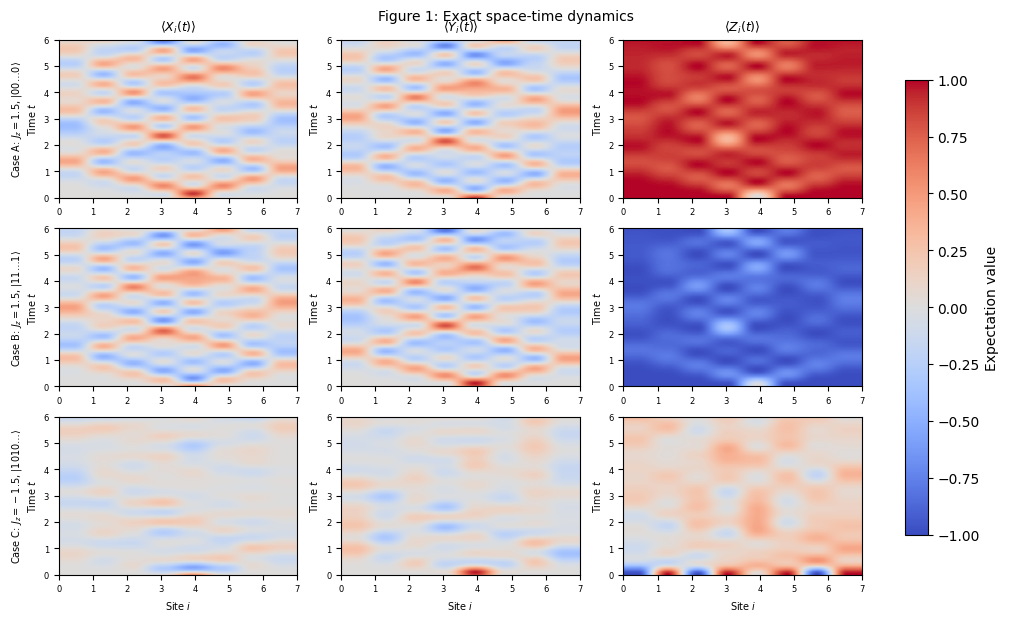

In [6]:
plot_figure1_exact_spacetime(exact_results, cases, times)

**Interpretation of Figure 1.**

- **Case A** ($J_z = 1.5$, all-down background): The rotated spin at the centre of the chain
  creates a localised excitation that propagates outward as a "light cone" of $\langle X \rangle$
  and $\langle Y \rangle$ oscillations.  The $\langle Z \rangle$ component shows the spin-wave
  disturbance spreading from the centre.  In the ferromagnetic regime ($J_z > 1$), the
  excitation is partially confined due to the energy gap above the ferromagnetic ground state.

- **Case B** ($J_z = 1.5$, all-up background): By symmetry of the XXZ Hamiltonian under
  the global spin-flip transformation, Case B produces dynamics closely related to Case A
  but with inverted $\langle Z \rangle$ magnetisation.  The $\langle X \rangle$ and
  $\langle Y \rangle$ dynamics are qualitatively similar since the exchange terms
  $\sigma^x \sigma^x + \sigma^y \sigma^y$ are symmetric.

- **Case C** ($J_z = -1.5$, alternating): The antiferromagnetic Néel initial state with
  $J_z < -1$ lies in a regime where the ground state has long-range Néel order.
  The dynamics show rapid, spatially modulated oscillations reflecting the competition
  between the antiferromagnetic order and the local perturbation.

## 6. Quantum Simulation Results: Qiskit Trotter Decomposition

<a id="6-quantum-simulation-results-trotter-decomposition"></a>

Following this, we simulate how a quantum computer would process the same initial states. We make use of the Qiskit framework to perform explicit gate operations on our state-vector. This is implemented by iterativley passing a 'QuantumCircuit' object containing one Trotter step circuit to the 'StateVector' object for each Trotter step. To minimize error in the Trotter decomposition, 2nd order symmetric trotter steps are performed; Where rotation gates are applied twice in opposing orders with half the time step interval. This simulation assumes the quantum gates are ideal and noise free. 

Figure 2 shows the simulation results in identical format to the previous section, while Figure 3 is the point-wise difference in the observable $\langle Z_i(t)\rangle$ between our Qiskit and classical results.



In [7]:
qiskit_results = {}

for case in cases:
    er = exact_results[case['name']]
    states_qiskit, obs_qiskit, bitstring, rotate_site = run_ideal_trotter(
        case, times, order=trotter_order)

    rmse = observable_rmse(er['obs'], obs_qiskit)
    infid = state_infidelity(er['states'][-1], states_qiskit[-1])

    qiskit_results[case['name']] = {
        'states': states_qiskit,
        'obs': obs_qiskit,
        'rmse': rmse,
        'infidelity': infid,
        'bitstring': bitstring,
        'rotate_site': rotate_site,
    }
    print(f"  {case['name']}:")
    print(f"    Observable RMSE (Qiskit Trotter vs exact) = {rmse:.6e}")
    print(f"    Final-state infidelity = {infid:.6e}")

  case_A_Jz_gt_1_all_down:
    Observable RMSE (Qiskit Trotter vs exact) = 1.098491e-02
    Final-state infidelity = 3.309404e-03
  case_B_Jz_gt_1_all_up:
    Observable RMSE (Qiskit Trotter vs exact) = 1.098491e-02
    Final-state infidelity = 3.309404e-03
  case_C_Jz_lt_minus1_alternating:
    Observable RMSE (Qiskit Trotter vs exact) = 5.453221e-03
    Final-state infidelity = 6.585047e-03


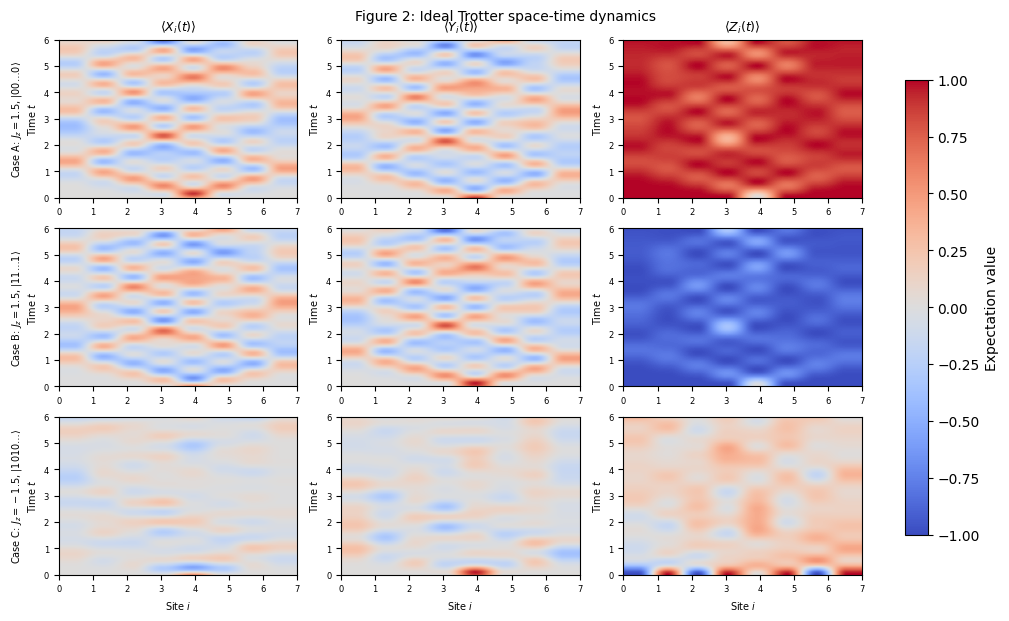

In [8]:
plot_figure2_ideal_trotter_spacetime(qiskit_results, cases, times)

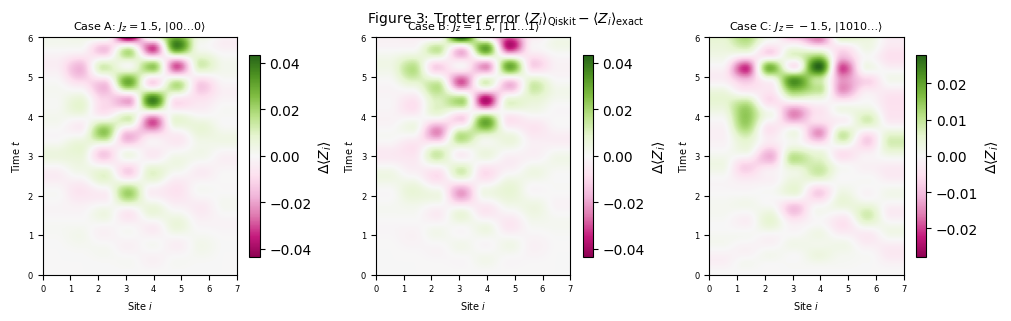

In [9]:
plot_figure3_trotter_error(qiskit_results, exact_results, cases, times)

**Interpretation of Figures 2 and 3.**

In each case, at this resolution the simulated quantum circuit yields indistinguishable results from our classical calculations in Figure 1. Suggesting that the second-order Trotter circuit with $\Delta t \approx 0.05$ is highly accurate for $L = 8$.  Analysis of Figure 3 shows that the residual error gets larger as number of time steps increases, and is most intense about the middle of the plot. This is expected as product-formula errors will accumulate over time, and error severity is determined by rapid changes in local dynamics. The errors are sufficiently small with respect to $\langle Z_i(t)\rangle$, allowing us to confirm high accuracy of this method for small timescales due predictable errors increasing over time.  
  
Quantitative metrics are summarized in Table 1 below.

In [10]:
print('Table 1: Ideal Qiskit second-order Trotter accuracy (121 time steps, dt = 0.05)')
print('=' * 74)
print(f'{"Case":<40} {"RMSE":>12} {"Infidelity":>14}')
print('-' * 74)
for case in cases:
    qr = qiskit_results[case['name']]
    print(f'{case["name"]:<40} {qr["rmse"]:>12.4e} {qr["infidelity"]:>14.4e}')
print('=' * 74)

Table 1: Ideal Qiskit second-order Trotter accuracy (121 time steps, dt = 0.05)
Case                                             RMSE     Infidelity
--------------------------------------------------------------------------
case_A_Jz_gt_1_all_down                    1.0985e-02     3.3094e-03
case_B_Jz_gt_1_all_up                      1.0985e-02     3.3094e-03
case_C_Jz_lt_minus1_alternating            5.4532e-03     6.5850e-03


## 7. Noisy Simulation Results

To simulate the impact of real hardware noise, we simulate the same Trotter circuits using `AerSimulator` together with a calibration-based noise model constructed from a real IBM backend. we connect to the IBM Quantum Platform and retrieve the calibration data of a real backend (here `ibm_fez`), and build the noisy simulator accordingly.

Subsequently, each Trotter loop is converted into a gate set compatible with the back end, so that back-end-derived noise channels—including gate errors, thermal relaxation, and readout errors—can be consistently applied to the simulation. The initial many-body state is precisely prepared, and the intermediate density matrix is saved at each time step to extract the observables.

This results in a deterministic evolution of the noisy density matrix, allowing us to compute the noisy observables directly from the simulated density matrix. Figure 4 compares the resulting noisy Aer $\langle Z_i(t)\rangle$ dynamics with the exact benchmarks for all three test cases.



In [11]:
# Connect to IBM Quantum and build noisy Aer simulator
service = QiskitRuntimeService()
real_backend = service.backend("ibm_fez")
noise_model = NoiseModel.from_backend(real_backend)
aer_sim = AerSimulator(noise_model=noise_model, method='density_matrix')

print(f"Backend: {real_backend.name}")

Backend: ibm_fez


In [12]:
noisy_results = {}

for case in cases:
    er = exact_results[case['name']]
    _, obs_noisy, bitstring, rotate_site = run_noisy_trotter(
        case, times, aer_backend=aer_sim, order=trotter_order)
    rmse = observable_rmse(er['obs'], obs_noisy)

    noisy_results[case['name']] = {
        'obs': obs_noisy,
        'rmse': rmse,
        'bitstring': bitstring,
        'rotate_site': rotate_site,
    }
    print(f"  {case['name']}:")
    print(f"    Noisy Aer ({real_backend.name}) vs exact RMSE = {rmse:.6e}")

  case_A_Jz_gt_1_all_down:
    Noisy Aer (ibm_fez) vs exact RMSE = 4.986687e-01
  case_B_Jz_gt_1_all_up:
    Noisy Aer (ibm_fez) vs exact RMSE = 5.358657e-01
  case_C_Jz_lt_minus1_alternating:
    Noisy Aer (ibm_fez) vs exact RMSE = 1.188033e-01


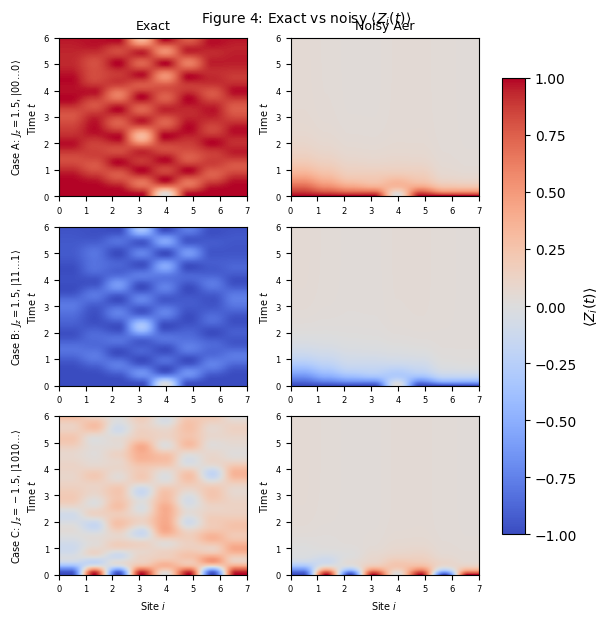

In [13]:
plot_figure4_exact_vs_noisy(exact_results, noisy_results, cases, times)

**Interpretation of Figure 4.**

Figure 4 shows that, after the initial moment, the noise-affected Aer simulation, even after back-end calibration, quickly fails to reproduce the precise spatiotemporal $\langle Z_i(t)\rangle$ dynamics. Although faint traces of the initial magnetization pattern can still be observed near $t=0$, the noise-affected results rapidly decay in both signal amplitude and spatial contrast. The oscillatory and interference-like structures clearly visible in the exact reference simulation are strongly suppressed once realistic device-level noise is introduced.

This effect is particularly pronounced in Cases A and B. A comparison reveals that in the exact dynamics, non-trivial propagating and spatial structures persist over a longer time domain, whereas in the noisy simulations, the magnetization rapidly collapses into a nearly featureless $\langle Z_i(t)\rangle \approx 0$ background. This indicates that in the translated Trotter circuit, decoherence, gate distortion, and readout-related noise accumulate rapidly, thereby erasing the features of many-body dynamics rather than merely introducing minor perturbations. Although the root-mean-square error (RMSE) in Case C is smaller than in Cases A and B, the figure shows that, due to the smaller amplitudes involved, the exact result in Case C already incorporates stronger cancellation effects and lower average contrast; consequently, the contribution of noise decaying to zero to the error is smaller. Therefore, the smaller RMSE in Case C does not necessarily imply better preservation of underlying coherence.

Overall, Figure 4 indicates that, for the current circuit depth and backend calibration noise model, actual hardware noise has become the primary limiting factor. Consequently, without further noise-conscious improvements, the current Trotter scheme cannot reliably capture long-term many-body dynamics. In future research, quantum error mitigation techniques could be explored to reduce biases in observable estimates and partially recover suppressed dynamical signals to improve the output results.





In [14]:
print("Table 2: Impact of Qiskit Aer gate noise on observable accuracy")
print("=" * 74)
print(f'{"Case":<40} {"Ideal Qiskit RMSE":>17} {"Noisy Aer RMSE":>16}')
print("-" * 74)
for case in cases:
    qr_rmse = qiskit_results[case['name']]['rmse']
    ns_rmse = noisy_results[case['name']]['rmse']
    print(f"{case['name']:<40} {qr_rmse:>17.4e} {ns_rmse:>16.4e}")
print("=" * 74)
print(f"\nNoise model: calibration data from {real_backend.name}")

Table 2: Impact of Qiskit Aer gate noise on observable accuracy
Case                                     Ideal Qiskit RMSE   Noisy Aer RMSE
--------------------------------------------------------------------------
case_A_Jz_gt_1_all_down                         1.0985e-02       4.9867e-01
case_B_Jz_gt_1_all_up                           1.0985e-02       5.3587e-01
case_C_Jz_lt_minus1_alternating                 5.4532e-03       1.1880e-01

Noise model: calibration data from ibm_fez


## 8. Error Scaling Analysis

<a id="8-error-scaling-analysis"></a>

A standard validation of the Trotter decomposition is verifying that the algorithm's convergence rate matches expectations.
For a $p$-th order product formula, the error in the final state should scale as
$\epsilon \propto (\Delta t^p)$ where $\Delta t = T/n$ is the timestep and $n$ is the number of Trotter steps. Substituting $\Delta t = T/n$ gives

$$
\epsilon \propto \left(\frac{T}{n}\right)^p
= T^p n^{-p}
$$


Taking the logarithm of both sides:

$$
\log \epsilon \propto \log(T^p n^{-p})
$$

Expanding the log,

$$
\log \Delta t^p \propto p\log T - p\log n
$$

Rearranging,

$$
\log \Delta t^p \propto -p\,\log n + p\log T
$$


This has the form:

$$
y = mx + c
$$

with

- $y = \log \Delta t^p$
- $x = \log n$
- slope $m = -p$

On a log-log plot, this corresponds to a straight line with slope $-p$, and thus we expect to see a straight line with slope
$-1$ and $-2$ for first- and second-order trotter decomposition respectively.

The following block of code computes this error scaling analysis with two different error choices.

- **Final-state infidelity**: This measures how different the exact and approximate quantum states are at the final time.
- **Observable RMSE**: This measures the root-mean-square deviation between exact and approximate observables at a given time.

Each are compared against values of $n \in \{20, 40, 80, 160\}$ Trotter steps, comparing first- and second-order ideal Qiskit
product-formula circuits against the exact benchmark (Figure 5).

### A) Final-state infidelity

If $|\psi_{\text{exact}}\rangle$ and $|\psi_{\text{trotter}}\rangle$ denote the exact and approximate states, the fidelity is

$$
F = |\langle \psi_{\text{exact}} | \psi_{\text{trotter}} \rangle|^2,
$$

The inner product $\langle \psi_{\text{exact}} | \psi_{\text{trotter}} \rangle$ measures the alignment of the two state vectors in Hilbert space, analogous to a dot product. The squared magnitude returns a probability of overlap between the two wave functions, therfore if the states are identical the fidelity is 1, whereas orthogonal states will have a fidelity of 0. 

The infidelity is then defined as:

$$
\text{infidelity} = 1 - F.
$$

This quantity is zero for identical states and increases as the two states diverge.

### B) Observable RMSE

If $O_{\text{exact}}(t_i)$ and $O_{\text{trotter}}(t_i)$ denote the observable values at time $t_i$, the RMSE is

$$
\text{RMSE} =
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
O_{\text{exact}}(t_i) -
O_{\text{trotter}}(t_i)
\right)^2
}.
$$

While the infidelity measures the error in the quantum state itself, the RMSE quantifies the error in the actual physically measured quantity.

In [15]:
error_data = {}

for case in cases:
    er = exact_results[case['name']]
    infid_1, infid_2, rmse_1, rmse_2 = [], [], [], []

    for n_steps in error_steps:
        times_n = np.linspace(0.0, t_max, n_steps + 1)
        exact_n = evolve_exact(er['H'], er['state0'], times_n)
        obs_exact_n = compute_all_observables(exact_n, case['L'])

        states_q1, obs_q1, _, _ = run_ideal_trotter(case, times_n, order=1)
        states_q2, obs_q2, _, _ = run_ideal_trotter(case, times_n, order=2)

        infid_1.append(state_infidelity(exact_n[-1], states_q1[-1]))
        infid_2.append(state_infidelity(exact_n[-1], states_q2[-1]))
        rmse_1.append(observable_rmse(obs_exact_n, obs_q1))
        rmse_2.append(observable_rmse(obs_exact_n, obs_q2))

    error_data[case['name']] = {
        'steps': list(error_steps),
        'infid_1': infid_1, 'infid_2': infid_2,
        'rmse_1': rmse_1, 'rmse_2': rmse_2,
    }
    print(f"  {case['name']}: error scaling computed")

  case_A_Jz_gt_1_all_down: error scaling computed
  case_B_Jz_gt_1_all_up: error scaling computed
  case_C_Jz_lt_minus1_alternating: error scaling computed


In [16]:
# Compute noisy (Aer) Trotter errors for 2nd-order only
# This shows that noise from deeper circuits can outweigh the Trotter accuracy gain

noisy_error_data = {}

for case in cases:
    er = exact_results[case['name']]
    infid_noisy, rmse_noisy = [], []

    for n_steps in error_steps:
        times_n = np.linspace(0.0, t_max, n_steps + 1)
        exact_n = evolve_exact(er['H'], er['state0'], times_n)
        obs_exact_n = compute_all_observables(exact_n, case['L'])

        dm_states, obs_noisy, _, _ = run_noisy_trotter(
            case, times_n, aer_backend=aer_sim, order=2)

        # Infidelity: 1 - <psi_exact|rho_noisy|psi_exact>
        infid_noisy.append(state_infidelity_dm(exact_n[-1], dm_states[-1]))
        rmse_noisy.append(observable_rmse(obs_exact_n, obs_noisy))

    noisy_error_data[case['name']] = {
        'steps': list(error_steps),
        'infid_noisy': infid_noisy,
        'rmse_noisy': rmse_noisy,
    }
    print(f"  {case['name']}: noisy error scaling computed")

  case_A_Jz_gt_1_all_down: noisy error scaling computed
  case_B_Jz_gt_1_all_up: noisy error scaling computed
  case_C_Jz_lt_minus1_alternating: noisy error scaling computed


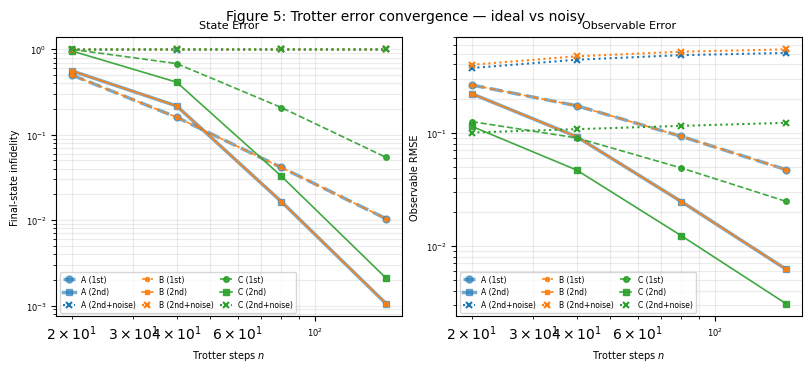

In [17]:
plot_figure5_error_convergence(error_data, noisy_error_data, cases)

**Interpretation of Figure 5.**

Figure 5 highlights the distinct roles played by Trotter errors and hardware noise. In an ideal scenario, both state errors and observable errors decrease as the number of Trotter steps $n$ increases, and the second-order Trotter method converges more rapidly for larger values of $n$. However, this trend largely disappears when noise simulated by Aer is introduced: further increasing $n$ yields almost no improvement and may even worsen the results, as deeper circuits introduce more noise. Thus, this figure demonstrates that on NISQ devices, more precise numerical approximations do not necessarily translate into better actual physical results.

It is worth noting that case A and B are exactly on top of each other, as they are their dynamics are the exact same (all up vs all down spins), this is why case A doesn't seem visible on the plot.

## 9. Spectral Analysis

<a id="9-spectral-analysis"></a>

The following block of code takes a two-dimensional Fourier transform of the magnetisation map $\langle Z_i(t)\rangle$, which depends on both site index $i$ and time $t$. 

The Fourier transform converts:

- variation in space $i$ → wave number $k$
- variation in time $t$ → frequency $\omega$

so that each point in the resulting $(k,\omega)$ plot shows how strongly a mode with wave number $k$ oscillates at frequency $\omega$.

In practice, we compute

$$
\left| \mathcal{F}_{2D}\!\left[\langle Z_i(t)\rangle\right] \right|,
$$

where the data for the $k=0$ is subtracted to remove the zero-frequency component. Without this subtraction, the static part of the signal (background noise) would dominate the spectrum and obscure the dynamical features. This is because a constant contribution, when Fourier transformed, produces a Dirac delta function at $k=0$ in the continuous case (or large peak in discrete FFT).

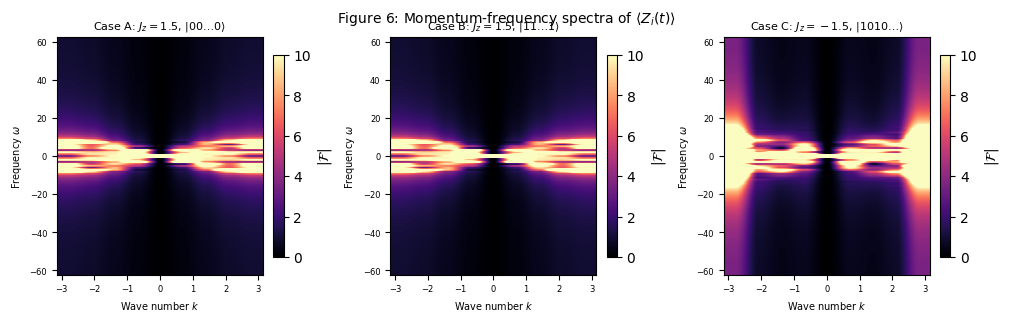

In [18]:
plot_figure6_fft_spectra(exact_results, cases, times)

**Interpretation of Figure 6.**

- **Cases A and B** ($J_z = 1.5$): Both of these ferromagnetic cases look the same, confirming that the dynamics are dominated by the hamiltonian, rather than the initial configurations (in this case all down vs all up spins). The band with $k=0$ is empty because it was removed as mentioned above, otherwise it drowns out the rest of the heatmap. Furthermore, there is a concentration of large spectral amplitudes at low angular frequencies, indicating that the dynamics favour low-energy excitations. Lastly there is also a dispersion of $w$ as $|k|$ increases. This reflects the dispersion of spin excitations, where shorter wavelength modes correspond to higher angular frequencies $w$.

- **Case C** ($J_z = -1.5$): The antiferromagnetic case shows similar results as the ferromagnetic case, except that it has a heavily populated band at $k = \pm \pi$. This is due to the fact that the antiferromagnetic case has a built-in periodicity of 2 (since spins are alternating), and $k = 2 \pi / \lambda$. This means that if the heatmap was extended to $k \in [-2\pi,2\pi]$, this pattern would repeat. It also explains why near the $k=0$ the dispersion of $w$ increases slightly.

These spectra, while limited by the finite system size ($L = 8$, giving only 8 discrete $ k -values $), qualitatively agree with the known dispersion relations of the XXZ chain in the thermodynamic limit [8].

## Optional: Real-Device Results

No real quantum hardware results were obtained for this project. All quantum results shown here
were generated with classical Qiskit simulators: ideal `Statevector` simulation for the noiseless
Trotter circuits and `AerSimulator` in density-matrix mode for the noisy circuit model. Executing
the same circuits on IBM Quantum hardware would provide an additional comparison point, but this
was not pursued due to hardware-access constraints and queue times.

## 10. Discussion

<a id="10-discussion"></a>

### 10.1 Summary of Method Comparison

We have evaluated three levels of simulation for the XXZ spin chain:

| Method | Error source | Typical RMSE | Controllable? |
|--------|-------------|-------------|---------------|
| Exact sparse evolution | Floating-point only | -- (reference) | N/A |
| Ideal Qiskit Trotter | Finite $\Delta t$ | $\sim 10^{-3}$- $10^{-2}$ | Yes (increase $n$) |
| Noisy Qiskit Aer Trotter | Gate noise + finite $\Delta t$ | $\sim 10^{-2}$- $10^{-1}$ | Partially |

The Qiskit Trotter decomposition faithfully reproduces the exact dynamics when $\Delta t$ is
sufficiently small, and the second-order formula provides a significant accuracy improvement
over the first order. This is an important methodological point: the circuit-level implementation
is not merely qualitatively correct, but quantitatively benchmarked against exact many-body
dynamics.

### 10.2 Noise as the Dominant Limitation

The Aer results show that even when the ideal Trotter approximation is highly accurate, gate-level
noise rapidly becomes the dominant source of error. In practice this means that for near-term
hardware, improving noise performance is at least as important as choosing a higher-order product
formula. The comparison between Figures 2 and 4 makes this especially clear: the ideal Qiskit
circuit tracks the exact dynamics closely, whereas the noisy circuit progressively washes out the
coherent structure quickly as time gose on.

The simulation results produced by Aer closely approximate real-world noise conditions; however, when actually running on quantum computing platforms such as IBM’s, Quantum Error Mitigation techniques—such as Zero-Noise Extrapolation (ZNE)—can be applied. This improves the noise-affected results to some extent, potentially making the final outcome closer to the ideal value than the “raw, unmitigated results from the actual hardware.”

Under fixed total evolution time and in an ideal, noise-free digital simulation, increasing the number of Trotter steps typically reduces Trotterization error. However, as the simulation results show, in this special case, noise is the dominant source of error. Increasing the number of steps make the circuit deeper and requires more quantum gates, which introduces more noise; consequently, the overall error increases rather than decreases as the number of steps increases. This also reminds us that in the current NISQ era of quantum computing, noise remains a critical factor that cannot be ignored, and in realistic applications, one expects an optimal Trotter step number that balances digital error against hardware noise.


### 10.3 Physical Interpretation

To elevate the “light-cone propagation” in the system from a qualitative picture to a physically grounded interpretation supported by quantitative evidence, we further analyze the propagation front, finite-size effects, and the behavior of conserved quantities.

First, we extract the empirical effective propagation velocity of the system by tracking the spatial front position $x_{\mathrm{front}}(t)$ of the local magnetization deviation $\Delta Z_i(t)=\langle Z_i(t)\rangle-\langle Z_i(0)\rangle$. As shown in Figure 7, for localized perturbations on an isotropic background (Cases A and B), $x_{\mathrm{front}}(t)$ exhibits a relatively clear, nearly linear growth in the early stages, with a linear fit yielding $v_{\mathrm{eff}} \approx 0.94$. At the same time, the signal outside the light cone is significantly weaker than that inside, indicating that the primary dynamics are concentrated near the finite-speed propagation front. This is consistent with the Lieb–Robinson-type effective causal structure under the short-range interaction Hamiltonian [13], supporting the picture of light-cone-like spreading in the system during the early stages. In contrast, for the interlaced initial state (Case C), the single-front extraction method is no longer equally effective. Since this initial state itself consists of a spatially extended interlaced pattern rather than a localized inversion on a uniform background, its dynamics are better understood as the redistribution and interference of global modes rather than the expansion of a single localized wavefront.

Secondly, given that the simulated system is finite and employs open boundary conditions, the dynamics will inevitably be affected by boundary reflections as $t$ increases [14]. Based on the extracted effective velocity, we estimate the reflection time for a finite system

$$
t_{\mathrm{refl}}\sim \frac{L/2}{v_{\mathrm{eff}}}
$$

which is approximately $t_{\mathrm{refl}}\approx 4.25$ under the current parameters. As shown in Figure 8, for $t < t_{\mathrm{refl}}$, the spatiotemporal heatmaps for Cases A and B primarily reflect the propagation front within the bulk phase; whereas after $t \gtrsim t_{\mathrm{refl}}$, the signal begins to interact with the boundary, generating reflections and producing interference patterns. Therefore, the interpretation here focuses primarily on the signal behavior at small $t$.

Finally, we use conserved quantities to verify the consistency of the numerical results. As shown in Figure 9, the total magnetization in the XXZ model

$$
M^z(t)=\sum_i \langle Z_i(t)\rangle
$$

remains essentially unchanged under both exact evolution and ideal Trotter evolution, indicating that the ideal quantum circuit preserves the model’s $U(1)$ symmetry well [15]. In contrast, the total magnetization in the noisy simulation decays rapidly with time, suggesting that noise disrupts the conserved structure originally guaranteed by the closed-system Hamiltonian and its symmetries. This also explains why the long-time coherent propagation features disappear more rapidly in the noisy results [16]. On the other hand, the energy $E(t) = \langle H\rangle$ remains strictly constant in the exact evolution, whereas under the ideal Trotter evolution, it exhibits small, bounded oscillations around the exact value [17]. This indicates that the discrete time step introduces controlled Trotter approximation errors, but the total energy does not exhibit any significant drift.

Taken together, these results indicate that the ideal Trotter circuit is already capable of reproducing the system’s primary propagation structure with reasonable stability, and that the primary factor truly responsible for the degradation of long-time results is the disruption of conserved quantities and coherence caused by noise.

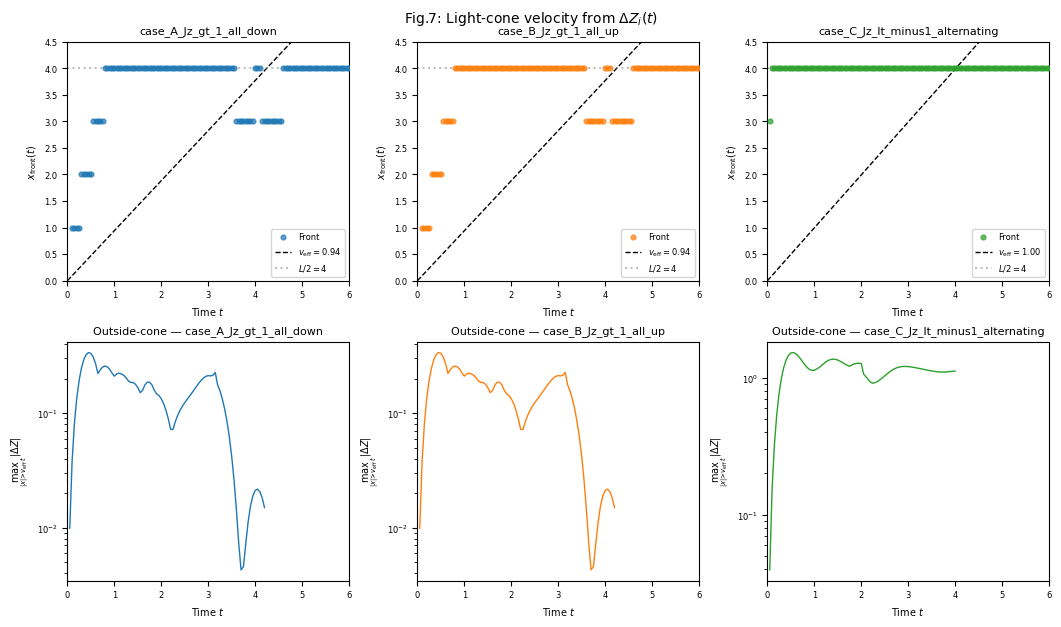

  case_A_Jz_gt_1_all_down: v_eff = 0.942
  case_B_Jz_gt_1_all_up: v_eff = 0.942
  case_C_Jz_lt_minus1_alternating: v_eff = 0.996


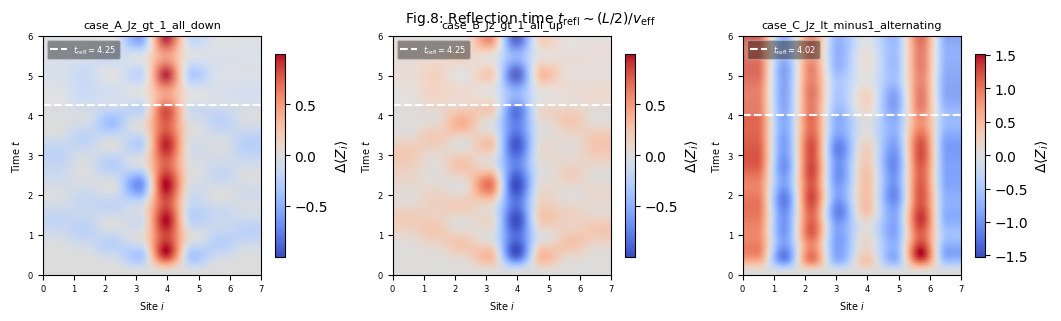

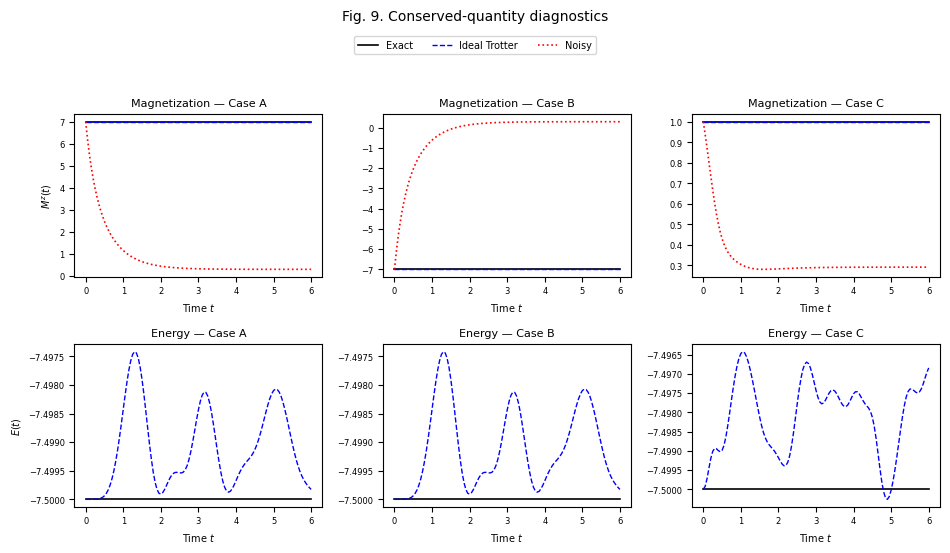

In [19]:
v_effs = plot_lightcone_velocity(exact_results, cases, times, threshold=0.02)
plot_reflection_time(exact_results, cases, times, v_effs=v_effs)
plot_conserved_quantities(
    exact_results, qiskit_results, noisy_results, cases, times
)


### 10.4 Scaling Outlook and the Simulation Bottleneck

When the system size is $L = 8$, simulation using classical computers remains straightforward. However, when we attempt to scale the system to $L = 12$, significant differences in computational cost emerge among different simulation methods, and the runtime increases substantially compared to the case of $L = 8$.



For a system with $L = 12$, although the Hilbert space dimension reaches $2^{12} = 4096$, an exact time evolution simulation using the classical dense matrix exponent (i.e., directly solving the evolution operator for the $4096 \times 4096$ Hamiltonian matrix) can be completed in approximately 5 minutes. If $L$ is further increased, sparse matrix algorithms can be used to optimize the simulation until we hit the true computational wall of classical computers at $L \approx 24$. However, for the same system with $L = 12$, when simulating a noisy Trotter circuit using Qiskit Aer, we found that the program ran for over an hour without producing any results. We can conclude that simulating a “noisy quantum circuit” on a classical computer consumes far more computational resources than directly solving the physical dynamics of a closed quantum system.



From the underlying mathematical principles, when the system is in an ideal, noise-free state, the classical simulator only needs to update and evolve a pure-state vector of size $2^L$. However, once non-unitary quantum hardware noise (such as depolarization channels) is introduced, the system state evolves into a mixed state. At this point, a classical simulator must either track a full density matrix that expands dramatically to $4^L$ (i.e., over 16 million elements), or use the Monte Carlo trajectory method to perform ensemble averaging on the results of thousands of random runs of the pure-state circuit. When this dimensional explosion is combined with the high-depth gate operations required for Trotter expansions (n time steps × a vast number of two-qubit gates), classical simulations of physical devices will hit the “exponential wall” sooner than simulations of the physical problem itself.

### 10.5 The Regime of Quantum Advantage

The exponential wall that classical simulations rapidly encounter when dealing with noisy systems serves as further evidence of why we need quantum hardware for physical simulations, as the computational complexities of the two approaches are not on the same order of magnitude. For a quantum system of size $L$, the time complexity for a classical computer to process this system grows exponentially as $\mathcal{O}(L \cdot 4^L)$. In contrast, processing the same system on a quantum computer requires only $L$ physical qubits, and the time complexity for the number of quantum gates corresponding to $n$ time steps is merely polynomial, $\mathcal{O}(L \cdot n)$. Without the need to compute massive density matrices, quantum computers directly carry and evolve this quantum state at the physical level, thereby avoiding the problem of dimensional explosion encountered on classical computers.

In terms of scale limits, when the system size reaches $L \approx 24$, the limit of exact diagonalization on classical computers is already reached; if $L$ reaches 44, even the the UK’s largest supercomputer, ARCHER2, would exhaust its memory trying to store a single quantum state [9]. In the range spanning $L \sim 50$, most of the classical methods fail, and we truly enter the realm of quantum supremacy.

However, in the current NISQ era, theoretical quantum supremacy does not necessarily translate to practical applications. Current superconducting quantum hardware (such as IBM’s Eagle, with 127 qubits) is operating at the very edge of this scale. Although their qubit counts exceed the limits of classical memory, the error rates of their two-qubit gates are on the order of $10^{-2}$ to $10^{-3}$. During long-time evolution with high circuit depth, the accumulation of noise will still rapidly erase the useful information in the quantum state [10].

Against this backdrop, recent studies have shown that even on NISQ devices lacking error-correcting mechanisms, physically meaningful simulation results can still be obtained at the hundred-qubit scale through quantum error mitigation. However, this relies on extensive sampling and post-processing, and in one-dimensional systems, it does not yield a significant advantage over traditional tensor network algorithms.
In contrast, in two-dimensional systems and under long-time evolution, the rapid growth of entanglement causes the cost of classical methods to rise exponentially. Similarly, in open systems/non-equilibrium quantum many-body systems, classical approximation methods often become inefficient or unreliable. In these systems, the potential advantages of quantum computing are more pronounced, as quantum devices can naturally represent highly entangled states without the exponential overhead faced by classical methods. [11].




## 11. Conclusion

<a id="11-conclusion"></a>


Overall, this project demonstrates that the algorithm used for the digital quantum simulation of the XXZ spin chain system is highly reliable, with minimal deviation from the exact solution; the approximation error of the algorithm is not the primary limitation at this stage. Under ideal conditions, the second-order Trotter circuit implemented using Qiskit can simulate the time evolution of the experimentally relevant $L=8$ system with small and controllable errors, while preserving key physical features such as system propagation, the diffusion of local perturbations, and conserved quantities. This indicates that this circuit model is both numerically and physically accurate.

In contrast, the noise introduced by quantum hardware is the primary factor limiting its current applications. Noisy simulations indicate that quantum gate errors rapidly suppress the system’s inherent coherence and erase the many-body structure during long-time evolution. Therefore, in the NISQ era, the more critical issue is not simply increasing the number of Trotter steps, but finding a balance between reducing Trotter errors and the noise introduced by increasing circuit depth. Although quantum advantages are not yet evident at the small system scales studied in this project, as system size, entanglement complexity, and the difficulty of non-equilibrium dynamics increase, the cost of classical simulations will rise rapidly. This is one of the areas where quantum computing is most likely to demonstrate its practical value in the future. Consequently, this project concludes that quantum computing holds clear potential for such many-body dynamics problems; however, for it to become a truly effective research tool, it will require future hardware with higher fidelity or more effective error mitigation techniques.

## 12. Contribution Statement

<a id="12-contribution-statement"></a>

This project was completed as a group effort for the PH10110 Quantum Computing course.
The contributions are as follows:

- **Classical exact-simulation code**:
  XXZ Hamiltonian construction via Kronecker products, exact time evolution using
  `scipy.linalg.expm`, and baseline observable analysis.
- **Qiskit circuit implementation**:
  initial-state preparation, first- and second-order Trotter circuits using `rxx`/`ryy`/`rzz`
  gates, and local observable extraction via `SparsePauliOp`.
- **Noisy circuit simulation**:
  Qiskit Aer density-matrix simulation with a custom Pauli gate-noise model.
- **Testing and validation**:
  cross-checks between exact and ideal Qiskit Trotter results, and convergence analysis.
- **Report writing and analysis**:
  self-contained notebook with all code, figure generation, physical interpretation,
  and presentation of results.

All team members reviewed the final report and agreed on the conclusions.

## 13. References

<a id="13-references"></a>

[1] I. M. Georgescu, S. Ashhab, and F. Nori, "Quantum simulation," *Rev. Mod. Phys.* **86**, 153 (2014).

[2] A. J. Daley, I. Bloch, C. Kokail, A. M. Rey, and P. Zoller, "Practical quantum advantage in quantum simulation," *Nature* **607**, 667–676 (2022).

[3] R. P. Feynman, "Simulating physics with computers," *Int. J. Theor. Phys.* **21**, 467–488 (1982).

[4] S. Lloyd, "Universal quantum simulators," *Science* **273**, 1073–1078 (1996).

[5] A. H. Al-Mohy and N. J. Higham, "Computing the action of the matrix exponential, with an application to exponential integrators," *SIAM J. Sci. Comput.* **33**, 488–511 (2011).

[6] E. Campbell, "Random compiler for fast Hamiltonian simulation," *Phys. Rev. Lett.* **123**, 070503 (2019).

[7] P. Krantz, M. Kjaergaard, F. Yan, T. P. Orlando, S. Gustavsson, and W. D. Oliver, "A quantum engineer's guide to superconducting qubits," *Appl. Phys. Rev.* **6**, 021318 (2019).

[8] M. Takahashi, *Thermodynamics of One-Dimensional Solvable Models* (Cambridge University Press, Cambridge, 1999).

[9] J. Smith, *Lecture slides 3 for PHYS10010: Quantum Computing* [Lecture slides], University of Edinburgh (2025).

[10] Y. Kim *et al*., "Evidence for the utility of quantum computing before fault tolerance," *Nature* **618**, 500–505 (2023).

[11] M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, Cambridge, 2000), p. 208.

[12] IBM Quantum Documentation, "RXXGate," online documentation. Available at: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RXXGate (accessed 18 March 2026).

[13] E. H. Lieb and D. W. Robinson, "The finite group velocity of quantum spin systems," *Commun. Math. Phys.* **28**, 251–257 (1972).

[14] F. H. L. Essler and M. Fagotti, "Quench dynamics and relaxation in isolated integrable quantum spin chains," *J. Stat. Mech.* **2016**, 064002 (2016).

[15] M. Ljubotina, M. Žnidarič, and T. Prosen, "Spin diffusion from an inhomogeneous quench in an integrable system," *Nat. Commun.* **8**, 16117 (2017).

[16] Qiskit Aer Documentation, "Device backend noise model simulations," online documentation. Available at: https://qiskit.github.io/qiskit-aer/tutorials/2_device_noise_simulation.html (accessed 18 March 2026).

[17] A. M. Childs, Y. Su, M. C. Tran, N. Wiebe, and S. Zhu, "Theory of Trotter Error with Commutator Scaling," *Phys. Rev. X* **11**, 011020 (2021).


